# Import Required Libraries
Import the necessary libraries, including pandas for data manipulation and matplotlib for plotting.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data from CSV File
Use pandas to read the an.csv file into a DataFrame.

In [3]:
df = pd.read_csv('an.csv')
print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (42, 2)


# Explore the Dataset
Display the first few rows of the dataset and check the data types to understand the structure.

In [4]:
print("First few rows:")
print(df.head())
print("\nData info:")
print(df.info())

First few rows:
         van        an
0 -63.983192  0.049521
1 -64.510526  0.034848
2 -57.918851  0.087121
3 -54.139624  0.082535
4 -52.030288  0.096291

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   van     42 non-null     float64
 1   an      42 non-null     float64
dtypes: float64(2)
memory usage: 804.0 bytes
None


# Bootstrap Analysis
Generate bootstrap samples and fit each to an = A*(vn+v05n)/(1-exp(-(vn+v05n)/z)) to estimate parameter uncertainties.

In [5]:
from scipy.optimize import curve_fit
import numpy as np

# Define the fitting function
def an_function(vn, A, v05n, z):
    return A * (vn + v05n) / (1 - np.exp(-(vn + v05n) / z))

# Initial guesses for parameters
initial_guess = [0.01, 55, 10]

# Bootstrap parameters
n_bootstrap = 4000
n_samples = len(df)

# Arrays to store bootstrap results
A_bootstrap = []
v05n_bootstrap = []
z_bootstrap = []

# Perform bootstrap resampling
np.random.seed(42)  # For reproducibility

for i in range(n_bootstrap):
    # Resample with replacement
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    van_resample = df['van'].iloc[indices].values
    an_resample = df['an'].iloc[indices].values
    
    try:
        # Fit the resampled data
        popt_boot, _ = curve_fit(an_function, van_resample, an_resample, p0=initial_guess)
        A_bootstrap.append(popt_boot[0])
        v05n_bootstrap.append(popt_boot[1])
        z_bootstrap.append(popt_boot[2])
    except:
        # Skip if fit fails
        continue

# Convert to numpy arrays
A_bootstrap = np.array(A_bootstrap)
v05n_bootstrap = np.array(v05n_bootstrap)
z_bootstrap = np.array(z_bootstrap)

print(f"Bootstrap Analysis Results (n={len(A_bootstrap)} successful fits):")
print(f"\nParameter A:")
print(f"  Mean = {np.mean(A_bootstrap):.6f}")
print(f"  Std  = {np.std(A_bootstrap):.6f}")
print(f"\nParameter v05n:")
print(f"  Mean = {np.mean(v05n_bootstrap):.6f}")
print(f"  Std  = {np.std(v05n_bootstrap):.6f}")
print(f"\nParameter z:")
print(f"  Mean = {np.mean(z_bootstrap):.6f}")
print(f"  Std  = {np.std(z_bootstrap):.6f}")

/var/folders/nw/qqw2xvy17fv7cxtzjlhg366r0000gn/T/ipykernel_58071/861704395.py:31: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_boot, _ = curve_fit(an_function, van_resample, an_resample, p0=initial_guess)


Bootstrap Analysis Results (n=4000 successful fits):

Parameter A:
  Mean = 0.009255
  Std  = 0.000417

Parameter v05n:
  Mean = 59.044882
  Std  = 2.860244

Parameter z:
  Mean = 6.899584
  Std  = 1.808530


/var/folders/nw/qqw2xvy17fv7cxtzjlhg366r0000gn/T/ipykernel_58071/861704395.py:6: RuntimeWarning: overflow encountered in exp
  return A * (vn + v05n) / (1 - np.exp(-(vn + v05n) / z))


# Plot Data with Bootstrap Mean Fit and Confidence Limits
Show the mean fit from bootstrap analysis with confidence intervals.

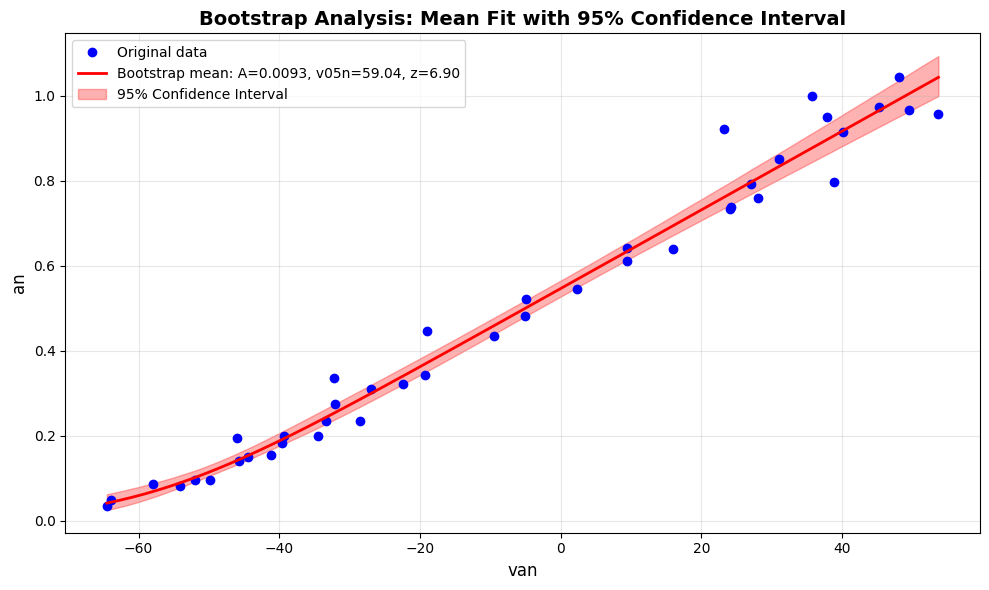

In [6]:
plt.figure(figsize=(10, 6))

# Plot original data
plt.plot(df['van'], df['an'], 'o', label='Original data', markersize=6, color='blue')

# Generate smooth curve for mean bootstrap fit
van_smooth = np.linspace(df['van'].min(), df['van'].max(), 200)
A_mean = np.mean(A_bootstrap)
v05n_mean = np.mean(v05n_bootstrap)
z_mean = np.mean(z_bootstrap)
an_mean = an_function(van_smooth, A_mean, v05n_mean, z_mean)

# Calculate confidence limits (95% CI using 2.5th and 97.5th percentiles)
an_curves = np.array([an_function(van_smooth, A_bootstrap[i], v05n_bootstrap[i], z_bootstrap[i]) 
                      for i in range(len(A_bootstrap))])
an_lower = np.percentile(an_curves, 2.5, axis=0)
an_upper = np.percentile(an_curves, 97.5, axis=0)

# Plot mean fit and confidence interval
plt.plot(van_smooth, an_mean, '-', linewidth=2, color='red', 
         label=f'Bootstrap mean: A={A_mean:.4f}, v05n={v05n_mean:.2f}, z={z_mean:.2f}')
plt.fill_between(van_smooth, an_lower, an_upper, alpha=0.3, color='red', 
                 label='95% Confidence Interval')

plt.xlabel('van', fontsize=12)
plt.ylabel('an', fontsize=12)
plt.title('Bootstrap Analysis: Mean Fit with 95% Confidence Interval', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histograms of Bootstrap Parameters
Distribution of A, v05n, and z from bootstrap resampling.

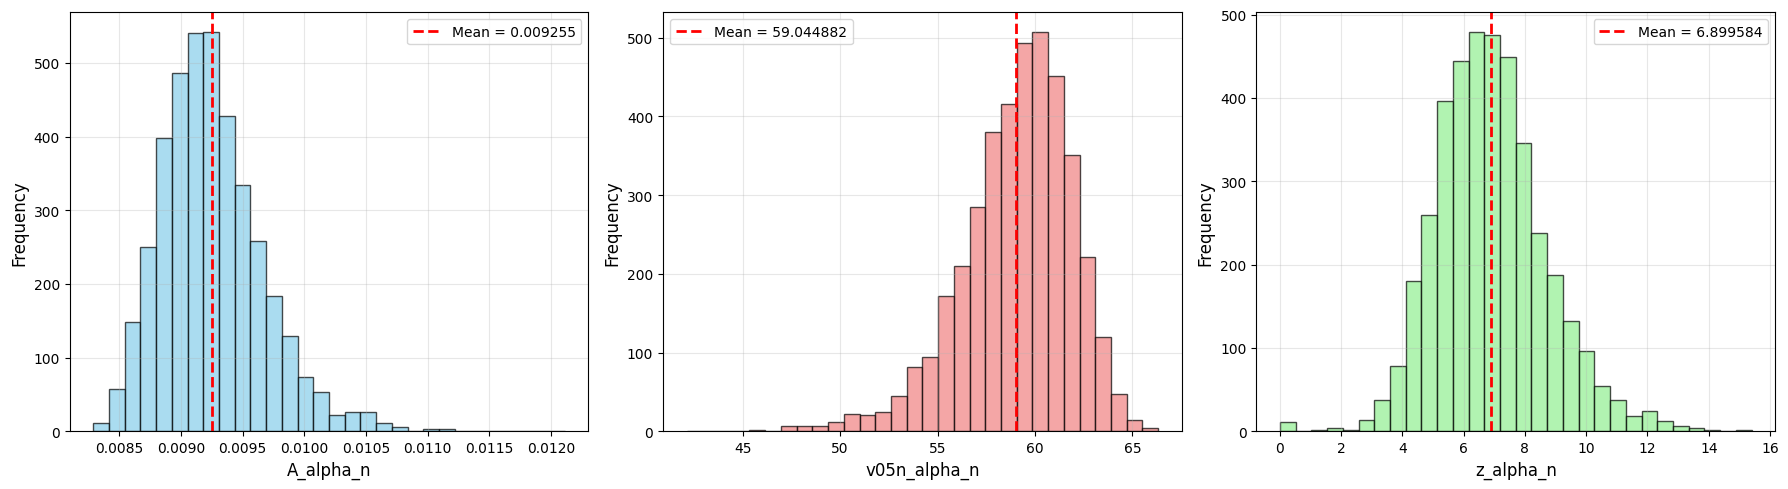

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of A
axes[0].hist(A_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(np.mean(A_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(A_bootstrap):.6f}')
axes[0].set_xlabel('A_alpha_n', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Histogram of v05n
axes[1].hist(v05n_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(np.mean(v05n_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(v05n_bootstrap):.6f}')
axes[1].set_xlabel('v05n_alpha_n', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Histogram of z
axes[2].hist(z_bootstrap, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].axvline(np.mean(z_bootstrap), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {np.mean(z_bootstrap):.6f}')
axes[2].set_xlabel('z_alpha_n', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Parameter Correlations
Scatter plots showing the relationships between fitted parameters from bootstrap samples.

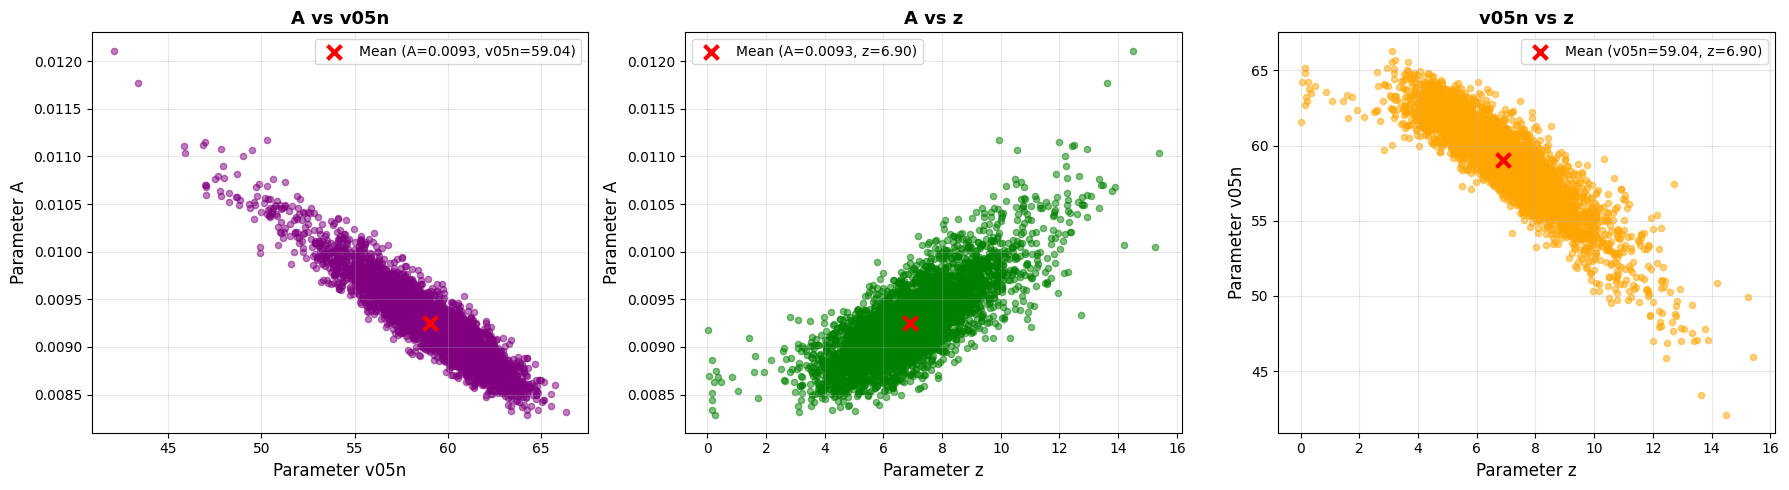


Correlation coefficients:
  A vs v05n: -0.9308
  A vs z:    0.7819
  v05n vs z: -0.8895


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate mean parameters
A_mean = np.mean(A_bootstrap)
v05n_mean = np.mean(v05n_bootstrap)
z_mean = np.mean(z_bootstrap)

# Scatter plot of A vs v05n
axes[0].scatter(v05n_bootstrap, A_bootstrap, alpha=0.5, s=20, color='purple')
axes[0].scatter(v05n_mean, A_mean, color='red', s=100, marker='x', linewidths=3, 
                label=f'Mean (A={A_mean:.4f}, v05n={v05n_mean:.2f})')
axes[0].set_xlabel('Parameter v05n', fontsize=12)
axes[0].set_ylabel('Parameter A', fontsize=12)
axes[0].set_title('A vs v05n', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Scatter plot of A vs z
axes[1].scatter(z_bootstrap, A_bootstrap, alpha=0.5, s=20, color='green')
axes[1].scatter(z_mean, A_mean, color='red', s=100, marker='x', linewidths=3, 
                label=f'Mean (A={A_mean:.4f}, z={z_mean:.2f})')
axes[1].set_xlabel('Parameter z', fontsize=12)
axes[1].set_ylabel('Parameter A', fontsize=12)
axes[1].set_title('A vs z', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Scatter plot of v05n vs z
axes[2].scatter(z_bootstrap, v05n_bootstrap, alpha=0.5, s=20, color='orange')
axes[2].scatter(z_mean, v05n_mean, color='red', s=100, marker='x', linewidths=3, 
                label=f'Mean (v05n={v05n_mean:.2f}, z={z_mean:.2f})')
axes[2].set_xlabel('Parameter z', fontsize=12)
axes[2].set_ylabel('Parameter v05n', fontsize=12)
axes[2].set_title('v05n vs z', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation coefficients
corr_A_v05n = np.corrcoef(A_bootstrap, v05n_bootstrap)[0, 1]
corr_A_z = np.corrcoef(A_bootstrap, z_bootstrap)[0, 1]
corr_v05n_z = np.corrcoef(v05n_bootstrap, z_bootstrap)[0, 1]

print(f"\nCorrelation coefficients:")
print(f"  A vs v05n: {corr_A_v05n:.4f}")
print(f"  A vs z:    {corr_A_z:.4f}")
print(f"  v05n vs z: {corr_v05n_z:.4f}")